# 08 — LoRA Inference: Config E

**Config E = SD Inpainting + LoRA(r=8)**  
Alternative approach — domain adaptation thuần, không có ControlNet hay IP-Adapter.

```
Ablation chain:
  A: SD only                      ← baseline
  B: SD + ControlNet              ← +shape prior
  C: SD + ControlNet + IP-Adapter ← +surface prior
  ─────────────────────────────────
  E: SD + LoRA          ← BẠN Ở ĐÂY (alternative)
  F: SD + LoRA + CN     ← future work
  G: SD + LoRA + CN + IP ← future work
```

```
project_root/
├── data/synthetic_occ/       ← output từ notebook 01
├── outputs/
│   ├── eval/                 ← từ notebook 05
│   ├── lora_weights/r8/best/ ← từ notebook 07
│   └── lora_sd/              ← Config E output
│       ├── x_hat/
│       ├── eval_gt_200/
│       ├── eval_pred_200/
│       └── reports/
```

**Chạy sau:** notebook 07  
**Chạy trước:** re-run notebook 05 → 06

In [1]:
# CELL 1 — Dependencies
import sys
!{sys.executable} -m pip install -q \
    "diffusers>=0.27.0" "peft>=0.8.0" "accelerate>=0.26.0" \
    "transformers>=4.36.0" scikit-image lpips clean-fid opencv-python
print("Dependencies ready")

Dependencies ready


In [2]:
# CELL 2 — Config & Paths
import random, json, time
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import cv2
from PIL import Image

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

PROJECT_ROOT = Path(".").resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

SYNTH_DIR = PROJECT_ROOT / "data" / "synthetic_occ"
GT_DIR    = SYNTH_DIR / "x_gt"
OCC_DIR   = SYNTH_DIR / "x_occ"
MASK_DIR  = SYNTH_DIR / "masks"
META_CSV  = SYNTH_DIR / "metadata_synthetic_occ.csv"
EVAL_CSV  = PROJECT_ROOT / "outputs" / "eval" / "metrics_per_image_A_SD_only.csv"

LORA_WEIGHTS = PROJECT_ROOT / "outputs" / "lora_weights" / "r8" / "best"
TRAIN_CFG    = PROJECT_ROOT / "outputs" / "lora_weights" / "r8" / "training_config.json"

SD_MODEL_ID = "runwayml/stable-diffusion-inpainting"

# Output dir Config E
LORA_SD_DIR   = PROJECT_ROOT / "outputs" / "lora_sd"
PRED_DIR      = LORA_SD_DIR / "x_hat"
EVAL_GT_DIR   = LORA_SD_DIR / "eval_gt_200"
EVAL_PRED_DIR = LORA_SD_DIR / "eval_pred_200"
REPORT_DIR    = LORA_SD_DIR / "reports"
for d in [PRED_DIR, EVAL_GT_DIR, EVAL_PRED_DIR, REPORT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# Dirs so sánh chart
XHAT_A = PROJECT_ROOT / "outputs" / "baseline_sd2"  / "x_hat"
XHAT_B = PROJECT_ROOT / "outputs" / "controlnet_sd" / "x_hat"
XHAT_C = PROJECT_ROOT / "outputs" / "controlnet_ip_sd" / "x_hat"

PROMPT     = "a car, realistic, high quality, detailed"
NEG_PROMPT = "blurry, distorted, artifacts"
NUM_STEPS  = 20
GUIDANCE   = 7.5
TEST_SIZE  = 200

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DTYPE  = torch.float16 if DEVICE == "cuda" else torch.float32

assert SYNTH_DIR.exists(), f"Dataset không tìm thấy: {SYNTH_DIR}"
if not LORA_WEIGHTS.exists():
    raise FileNotFoundError(f"LoRA weights không tìm thấy: {LORA_WEIGHTS}\n→ Chạy 07 trước!")

train_cfg = json.loads(TRAIN_CFG.read_text()) if TRAIN_CFG.exists() else {}
lora_rank = train_cfg.get("lora_rank", 8)
meta      = pd.read_csv(META_CSV)
meta.columns = meta.columns.str.strip().str.lower()

print(f"Device       : {DEVICE}")
print(f"Project root : {PROJECT_ROOT}")
print(f"LoRA weights : {LORA_WEIGHTS}  (r={lora_rank}, best_val={train_cfg.get('best_val_loss','N/A')})")
print(f"Output       : {LORA_SD_DIR}")
print(f"Config E     : SD Inpainting + LoRA(r={lora_rank}) ONLY")
print(f"  (không ControlNet, không IP-Adapter)")
print(f"Metadata     : {len(meta):,} rows")

Device       : cuda
Project root : D:\CS331\DoAn\Occluded-Object-Restoration-CarsFocus
LoRA weights : D:\CS331\DoAn\Occluded-Object-Restoration-CarsFocus\outputs\lora_weights\r8\best  (r=8, best_val=0.011640875253360718)
Output       : D:\CS331\DoAn\Occluded-Object-Restoration-CarsFocus\outputs\lora_sd
Config E     : SD Inpainting + LoRA(r=8) ONLY
  (không ControlNet, không IP-Adapter)
Metadata     : 11,254 rows


In [3]:
# CELL 3 — Load Pipeline Config E
# SD Inpainting + LoRA(r=8) fused — không ControlNet, không IP-Adapter
# Không dùng xformers
from diffusers import StableDiffusionInpaintPipeline, DPMSolverMultistepScheduler
from peft import PeftModel

print("Loading SD Inpainting pipeline (no ControlNet)...")
pipe = StableDiffusionInpaintPipeline.from_pretrained(
    SD_MODEL_ID, torch_dtype=DTYPE, safety_checker=None, requires_safety_checker=False,
)
pipe.scheduler = DPMSolverMultistepScheduler.from_config(pipe.scheduler.config)

print(f"Loading & fusing LoRA r={lora_rank}...")
pipe.unet = PeftModel.from_pretrained(pipe.unet, str(LORA_WEIGHTS))
pipe.unet = pipe.unet.merge_and_unload()
print("LoRA fused.")

pipe = pipe.to(DEVICE)
pipe.enable_attention_slicing("auto")
pipe.vae.enable_slicing()

print(f"\nPipeline ready — Config E")
print(f"  SD + LoRA(r={lora_rank}) only")
print(f"  ControlNet  : False")
print(f"  IP-Adapter  : False")
print(f"  Scheduler   : {pipe.scheduler.__class__.__name__}")

c:\Users\Admin\anaconda3\envs\lora_311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading SD Inpainting pipeline (no ControlNet)...


unet\diffusion_pytorch_model.safetensors not found
Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]c:\Users\Admin\anaconda3\envs\lora_311\Lib\site-packages\transformers\tokenization_utils_base.py:1617: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be deprecated in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(
An error occurred while trying to fetch C:\Users\Admin\.cache\huggingface\hub\models--runwayml--stable-diffusion-inpainting\snapshots\8a4288a76071f7280aedbdb3253bdb9e9d5d84bb\vae: Error no file named diffusion_pytorch_model.safetensors found in directory C:\Users\Admin\.cache\huggingface\hub\models--runwayml--stable-diffusion-inpainting\snapshots\8a4288a76071f7280aedbdb3253bdb9e9d5d84bb\vae.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an err

Loading & fusing LoRA r=8...
LoRA fused.

Pipeline ready — Config E
  SD + LoRA(r=8) only
  ControlNet  : False
  IP-Adapter  : False
  Scheduler   : DPMSolverMultistepScheduler


In [4]:
# CELL 4 — Helper Functions
from skimage.metrics import structural_similarity as ssim_fn
import lpips as lpips_lib

lpips_model = lpips_lib.LPIPS(net="alex").to(DEVICE).eval()


def masked_ssim(gt, pred, m):
    _, smap = ssim_fn(gt/255., pred/255., channel_axis=2, data_range=1.0, full=True)
    return float(smap[m.astype(bool)].mean()) if m.sum() > 0 else float(smap.mean())


def masked_lpips(gt, pred, m):
    mf   = m.astype(np.float32)[..., None]
    gt_t = torch.from_numpy((gt*mf).astype(np.uint8)).permute(2,0,1).unsqueeze(0).float()/127.5-1.
    pr_t = torch.from_numpy((pred*mf).astype(np.uint8)).permute(2,0,1).unsqueeze(0).float()/127.5-1.
    with torch.no_grad():
        return float(lpips_model(gt_t.to(DEVICE), pr_t.to(DEVICE)).item())


def inpaint_e(image, mask, prompt, seed=SEED):
    """Config E: SD Inpainting + LoRA(fused), không conditioning bổ sung."""
    gen = torch.Generator(device=DEVICE).manual_seed(seed)
    if DEVICE == "cuda":
        with torch.autocast("cuda"):
            out = pipe(
                prompt=prompt, negative_prompt=NEG_PROMPT,
                image=image, mask_image=mask,
                num_inference_steps=NUM_STEPS, guidance_scale=GUIDANCE,
                generator=gen,
            ).images[0]
    else:
        out = pipe(
            prompt=prompt, negative_prompt=NEG_PROMPT,
            image=image, mask_image=mask,
            num_inference_steps=NUM_STEPS, guidance_scale=GUIDANCE,
            generator=gen,
        ).images[0]
    return out


print("Helper functions defined.")

Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]


c:\Users\Admin\anaconda3\envs\lora_311\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\Admin\anaconda3\envs\lora_311\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loading model from: c:\Users\Admin\anaconda3\envs\lora_311\Lib\site-packages\lpips\weights\v0.1\alex.pth
Helper functions defined.


c:\Users\Admin\anaconda3\envs\lora_311\Lib\site-packages\lpips\lpips.py:107: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.load_state_dict(torch.load(model_path, map_lo

In [5]:
# CELL 5 — Full Inference 200 ảnh
# Config E không có scale params → không cần grid search
# Test set giống hệt 02/03/04 (SEED=42)
from tqdm.auto import tqdm

test_df = meta.sample(TEST_SIZE, random_state=SEED).reset_index(drop=True)
print(f"Test set : {len(test_df)} ảnh")
print(f"Config E : SD + LoRA(r={lora_rank}) only — không grid search")

pred_records = []
t0 = time.time()

for idx, r in tqdm(test_df.iterrows(), total=len(test_df), desc="Config E inference"):
    occ  = Image.open(OCC_DIR  / r["x_occ"]).convert("RGB").resize((512,512))
    msk  = Image.open(MASK_DIR / f"{r['stem']}.png").convert("L").resize((512,512))
    gt   = Image.open(GT_DIR   / r["x_gt"]).convert("RGB").resize((512,512))
    pred = inpaint_e(occ, msk, PROMPT)
    name = f"{r['stem']}.png"
    pred.save(PRED_DIR / name)
    gt.save(EVAL_GT_DIR / name)
    pred.save(EVAL_PRED_DIR / name)
    pred_records.append({
        "stem": r["stem"], "x_gt": r["x_gt"], "x_occ": r["x_occ"],
        "occlusion_ratio": r["occlusion_ratio"], "pred": name,
    })

infer_elapsed = time.time() - t0
pred_df = pd.DataFrame(pred_records)
print(f"Inference done: {len(pred_df)} ảnh trong {infer_elapsed/60:.1f} min")

Test set : 200 ảnh
Config E : SD + LoRA(r=8) only — không grid search


Config E inference: 100%|██████████| 200/200 [17:19<00:00,  5.20s/it]

Inference done: 200 ảnh trong 17.3 min


In [6]:
# CELL 6 — Metrics (SSIM / LPIPS / FID)
from cleanfid import fid

metric_rows = []
for _, r in tqdm(pred_df.iterrows(), total=len(pred_df), desc="Metrics"):
    gt   = cv2.cvtColor(cv2.imread(str(GT_DIR   / r["x_gt"])),  cv2.COLOR_BGR2RGB)
    pr   = cv2.cvtColor(cv2.imread(str(PRED_DIR / r["pred"])), cv2.COLOR_BGR2RGB)
    gt   = cv2.resize(gt, (512,512)); pr = cv2.resize(pr, (512,512))
    mk01 = (cv2.resize(
        cv2.imread(str(MASK_DIR/f"{r['stem']}.png"), cv2.IMREAD_GRAYSCALE),
        (512,512)) > 127).astype(np.uint8)
    metric_rows.append({
        "stem": r["stem"], "occlusion_ratio": r["occlusion_ratio"],
        "ssim": masked_ssim(gt, pr, mk01), "lpips": masked_lpips(gt, pr, mk01),
    })

metric_df = pd.DataFrame(metric_rows)
print("Computing FID...")
fid_value = fid.compute_fid(str(EVAL_GT_DIR), str(EVAL_PRED_DIR), mode="clean", num_workers=0)

summary = {
    "config"             : "E_LoRA_only",
    "model"              : f"{SD_MODEL_ID} + LoRA(r={lora_rank})",
    "scheduler"          : pipe.scheduler.__class__.__name__,
    "num_test_images"    : int(len(metric_df)),
    "steps"              : int(NUM_STEPS), "guidance": float(GUIDANCE),
    "cn_scale"           : None, "ip_scale": None,
    "lora_rank"          : int(lora_rank),
    "lora_best_val_loss" : float(train_cfg.get("best_val_loss", 0)),
    "use_controlnet"     : False, "use_ip_adapter": False,
    "ssim_mean"          : float(metric_df["ssim"].mean()),
    "lpips_mean"         : float(metric_df["lpips"].mean()),
    "fid"                : float(fid_value),
    "inference_minutes"  : float(infer_elapsed / 60),
    "xformers": False, "attention_slicing": True,
}

metric_df.to_csv(REPORT_DIR / "E_LoRA_only_metrics_per_image.csv", index=False)
pd.DataFrame([summary]).to_csv(REPORT_DIR / "E_LoRA_only_summary.csv", index=False)

print("=" * 55)
print(f"Config E (SD + LoRA r={lora_rank} only):")
print(f"  SSIM  mean : {summary['ssim_mean']:.4f}")
print(f"  LPIPS mean : {summary['lpips_mean']:.4f}")
print(f"  FID        : {summary['fid']:.2f}")
print("=" * 55)

Metrics: 100%|██████████| 200/200 [00:36<00:00,  5.50it/s]


Computing FID...
compute FID between two folders
Found 400 images in the folder D:\CS331\DoAn\Occluded-Object-Restoration-CarsFocus\outputs\lora_sd\eval_gt_200


FID eval_gt_200 : 100%|██████████| 13/13 [00:13<00:00,  1.03s/it]


Found 400 images in the folder D:\CS331\DoAn\Occluded-Object-Restoration-CarsFocus\outputs\lora_sd\eval_pred_200


FID eval_pred_200 : 100%|██████████| 13/13 [00:12<00:00,  1.01it/s]


Config E (SD + LoRA r=8 only):
  SSIM  mean : 0.5925
  LPIPS mean : 0.0573
  FID        : 22.10


In [7]:
# CELL 7 — Xuất ablation_row_E.csv
ablation_row = {
    "config"             : "E_LoRA_only",
    "model"              : summary["model"],
    "SSIM"               : summary["ssim_mean"],
    "LPIPS"              : summary["lpips_mean"],
    "FID"                : summary["fid"],
    "num_test"           : summary["num_test_images"],
    "steps"              : summary["steps"],
    "guidance"           : summary["guidance"],
    "scheduler"          : summary["scheduler"],
    "cn_scale"           : "N/A", "ip_scale": "N/A",
    "lora_rank"          : summary["lora_rank"],
    "lora_best_val_loss" : summary["lora_best_val_loss"],
    "use_controlnet"     : False, "use_ip_adapter": False,
}
pd.DataFrame([ablation_row]).to_csv(REPORT_DIR / "ablation_row_E.csv", index=False)
print(f"Saved: {REPORT_DIR}/ablation_row_E.csv")
print()
print("─── Tích hợp vào notebook 05 (thêm vào CELL 3) ───")
print(f"  E_REPORT_DIR = Path('{REPORT_DIR}')")
print( "  e_pi = E_REPORT_DIR / 'E_LoRA_only_metrics_per_image.csv'")
print( "  if e_pi.exists():")
print( "      PER_IMAGE_SRC['E_LoRA_only'] = e_pi")
print( "      SUMMARY_SRC['E_LoRA_only']   = E_REPORT_DIR / 'E_LoRA_only_summary.csv'")
print(f"      XHAT_DIRS['E_LoRA_only']     = Path('{PRED_DIR}')")
print( "      ACTIVE.append('E_LoRA_only')")

Saved: D:\CS331\DoAn\Occluded-Object-Restoration-CarsFocus\outputs\lora_sd\reports/ablation_row_E.csv

─── Tích hợp vào notebook 05 (thêm vào CELL 3) ───
  E_REPORT_DIR = Path('D:\CS331\DoAn\Occluded-Object-Restoration-CarsFocus\outputs\lora_sd\reports')
  e_pi = E_REPORT_DIR / 'E_LoRA_only_metrics_per_image.csv'
  if e_pi.exists():
      PER_IMAGE_SRC['E_LoRA_only'] = e_pi
      SUMMARY_SRC['E_LoRA_only']   = E_REPORT_DIR / 'E_LoRA_only_summary.csv'
      XHAT_DIRS['E_LoRA_only']     = Path('D:\CS331\DoAn\Occluded-Object-Restoration-CarsFocus\outputs\lora_sd\x_hat')
      ACTIVE.append('E_LoRA_only')


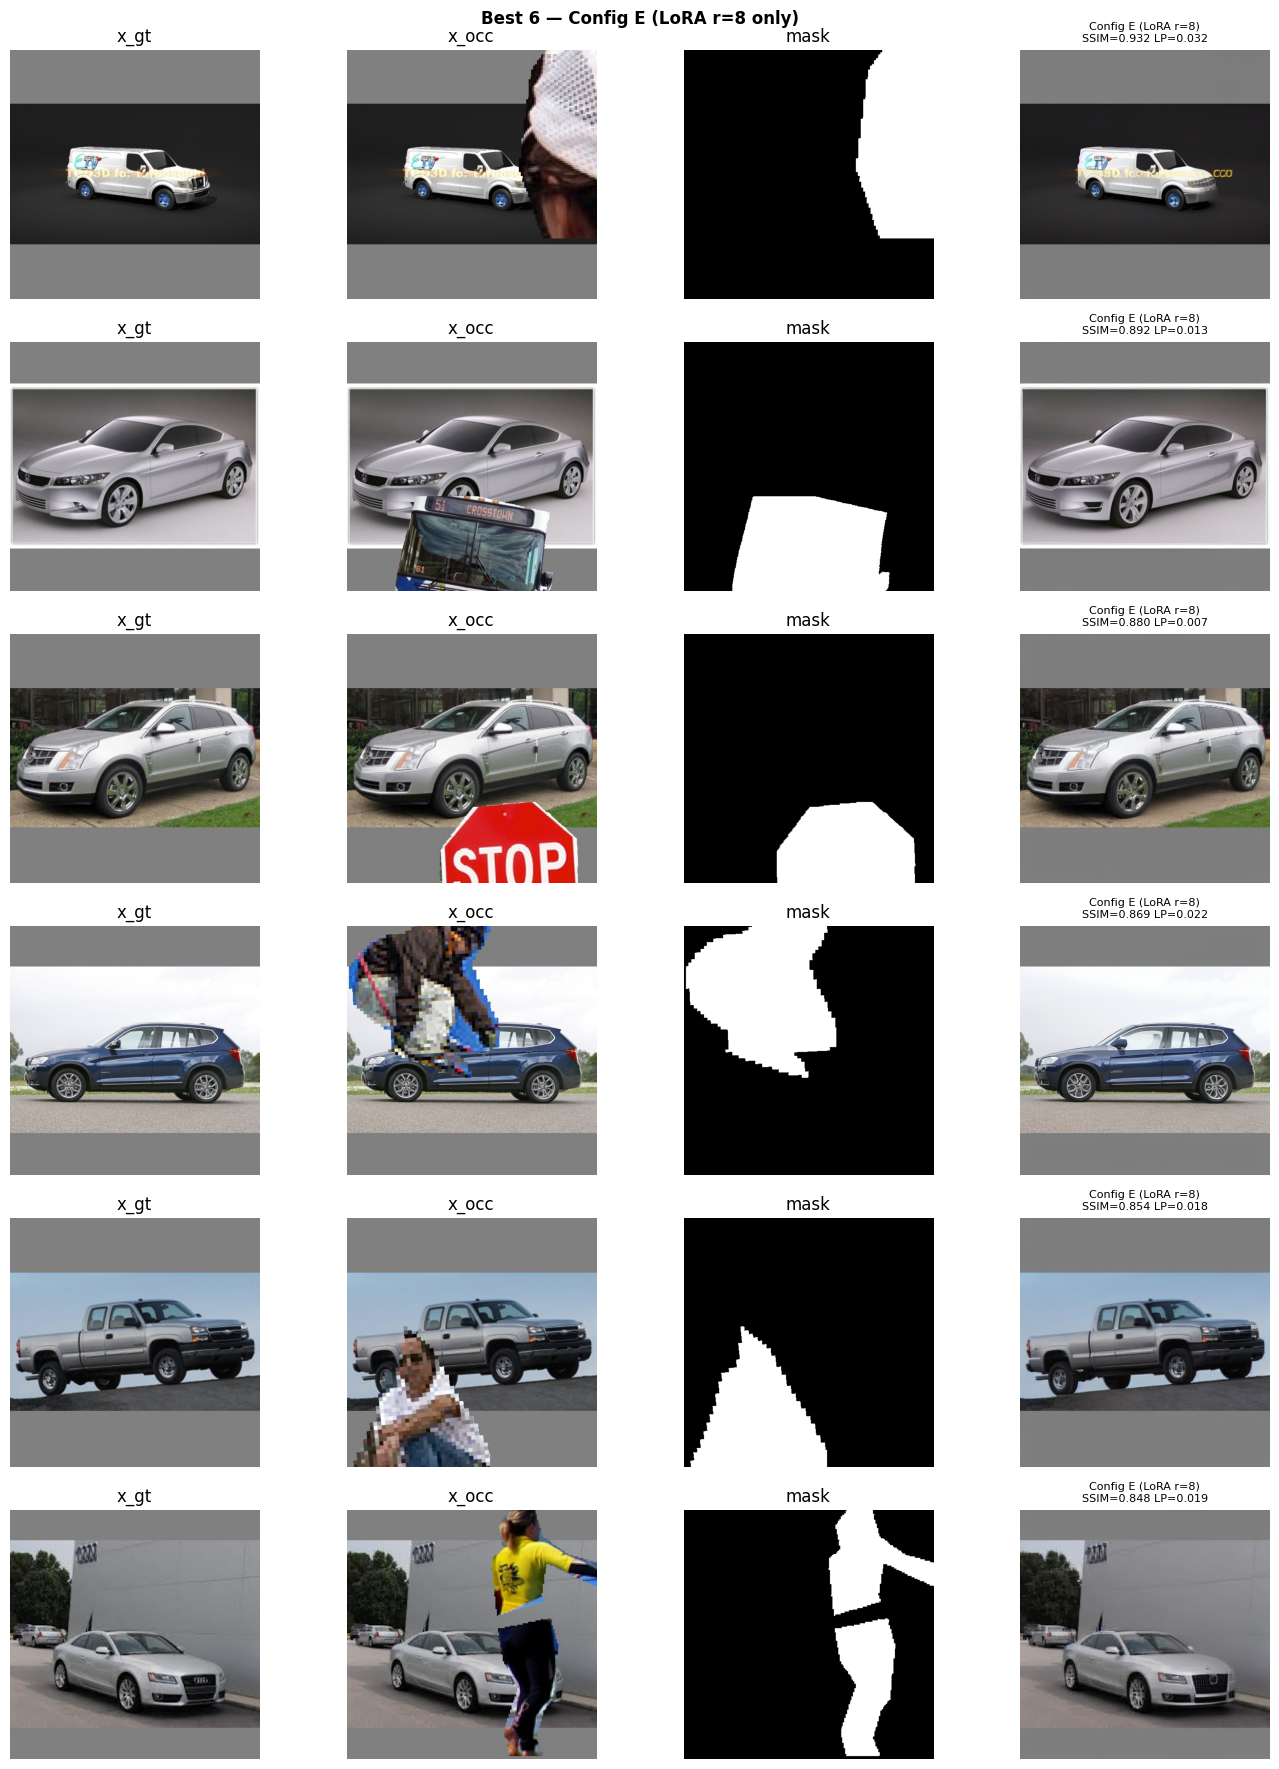

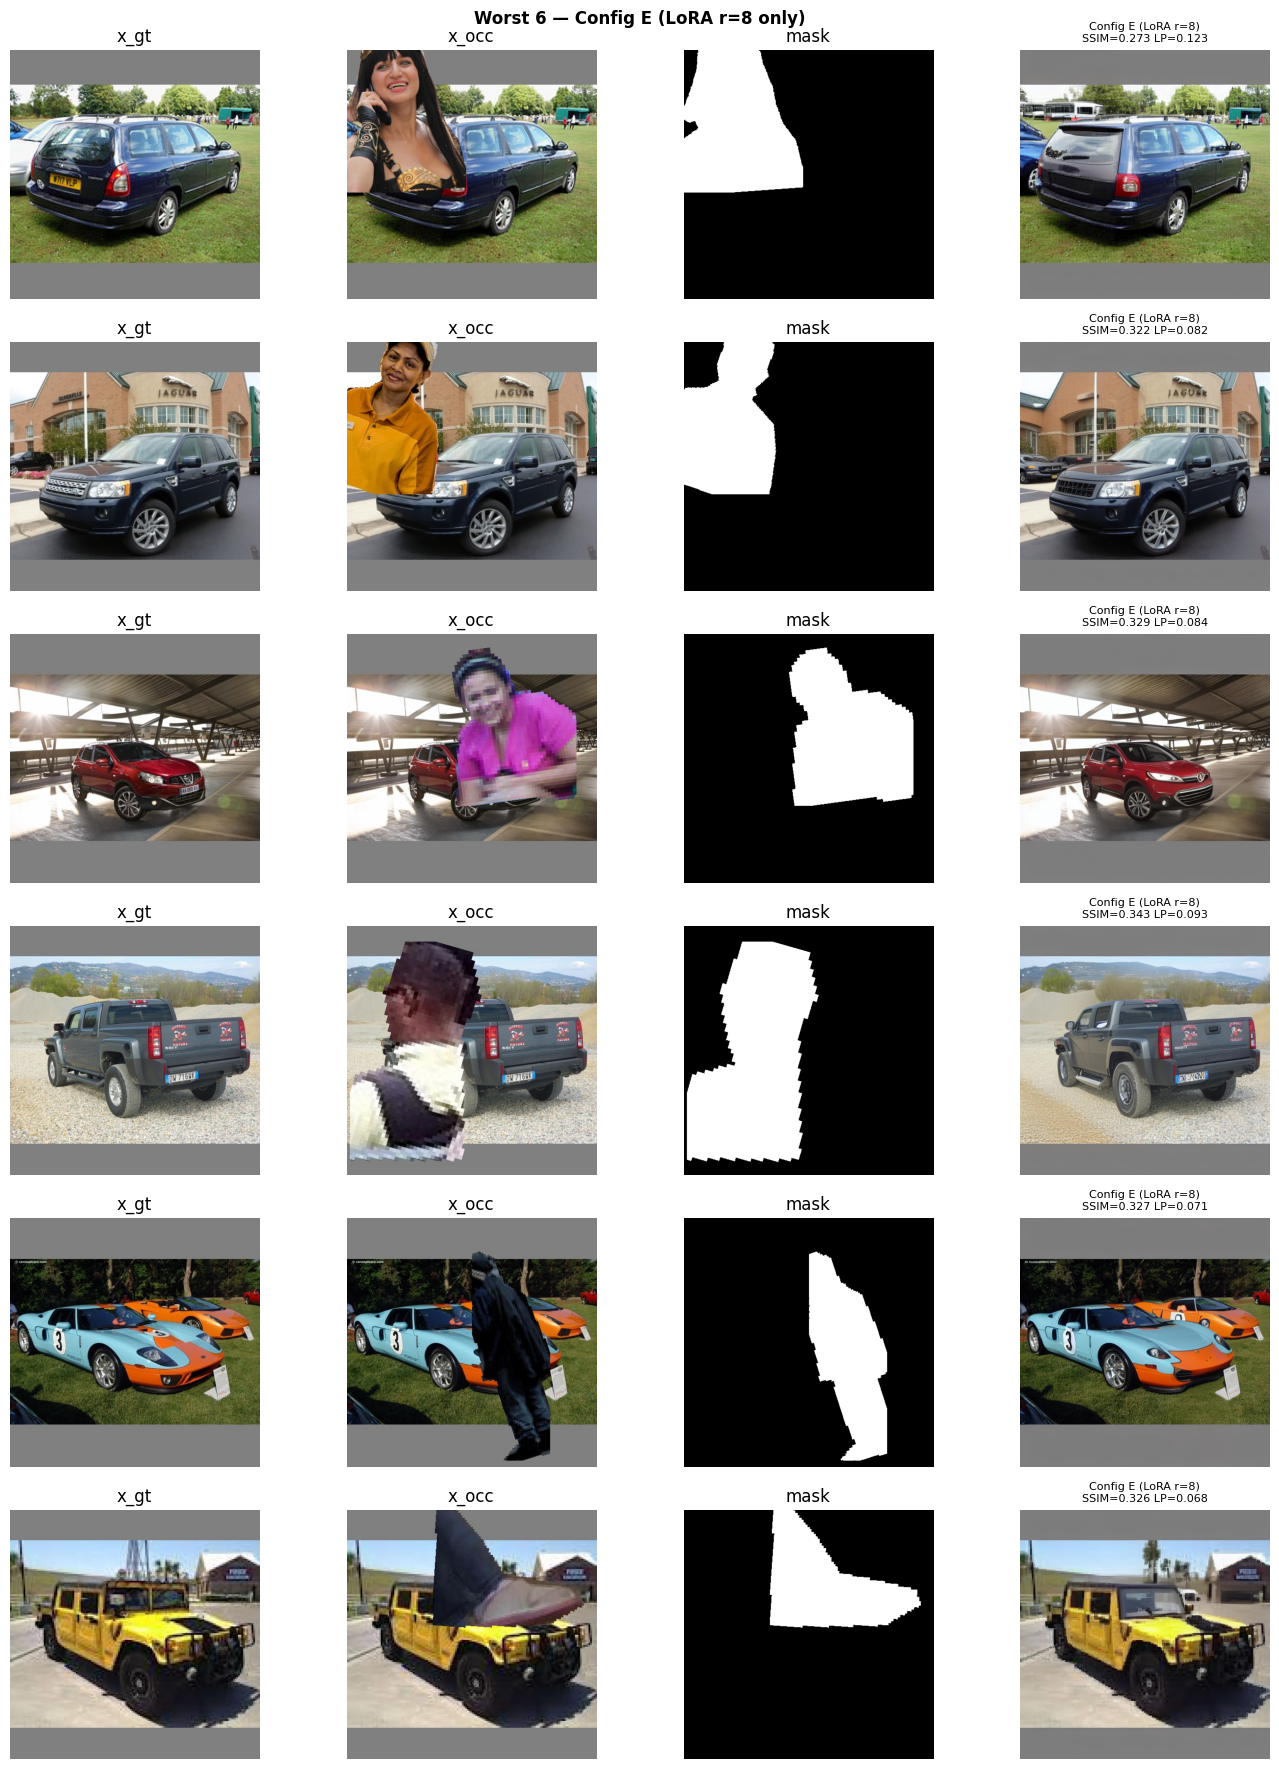

In [8]:
# CELL 8 — Visualize Best / Worst Cases
import matplotlib.pyplot as plt

analysis_df = metric_df.copy()
analysis_df["score"] = analysis_df["ssim"] - analysis_df["lpips"]
best20  = analysis_df.sort_values("score", ascending=False).head(20)
worst20 = analysis_df.sort_values("score", ascending=True).head(20)
best20.to_csv(REPORT_DIR  / "best20_cases.csv",  index=False)
worst20.to_csv(REPORT_DIR / "worst20_cases.csv", index=False)


def show_cases(case_df, title, n=6):
    n = min(n, len(case_df))
    fig, axes = plt.subplots(n, 4, figsize=(14, 3*n))
    if n == 1: axes = np.expand_dims(axes, 0)
    for i, (_, row) in enumerate(case_df.head(n).iterrows()):
        stem = row["stem"]
        rr   = pred_df[pred_df["stem"]==stem].iloc[0]
        gt   = Image.open(EVAL_GT_DIR   / f"{stem}.png").convert("RGB")
        pr   = Image.open(EVAL_PRED_DIR / f"{stem}.png").convert("RGB")
        occ  = Image.open(OCC_DIR / rr["x_occ"]).convert("RGB")
        msk  = Image.open(MASK_DIR / f"{stem}.png").convert("L")
        axes[i,0].imshow(gt);               axes[i,0].set_title("x_gt")
        axes[i,1].imshow(occ);              axes[i,1].set_title("x_occ")
        axes[i,2].imshow(msk, cmap="gray"); axes[i,2].set_title("mask")
        axes[i,3].imshow(pr);               axes[i,3].set_title(
            f"Config E (LoRA r={lora_rank})\nSSIM={row['ssim']:.3f} LP={row['lpips']:.3f}",
            fontsize=8)
        for ax in axes[i]: ax.axis("off")
    plt.suptitle(title, fontsize=12, fontweight="bold")
    plt.tight_layout(); plt.show()


show_cases(best20,  f"Best 6 — Config E (LoRA r={lora_rank} only)")
show_cases(worst20, f"Worst 6 — Config E (LoRA r={lora_rank} only)")

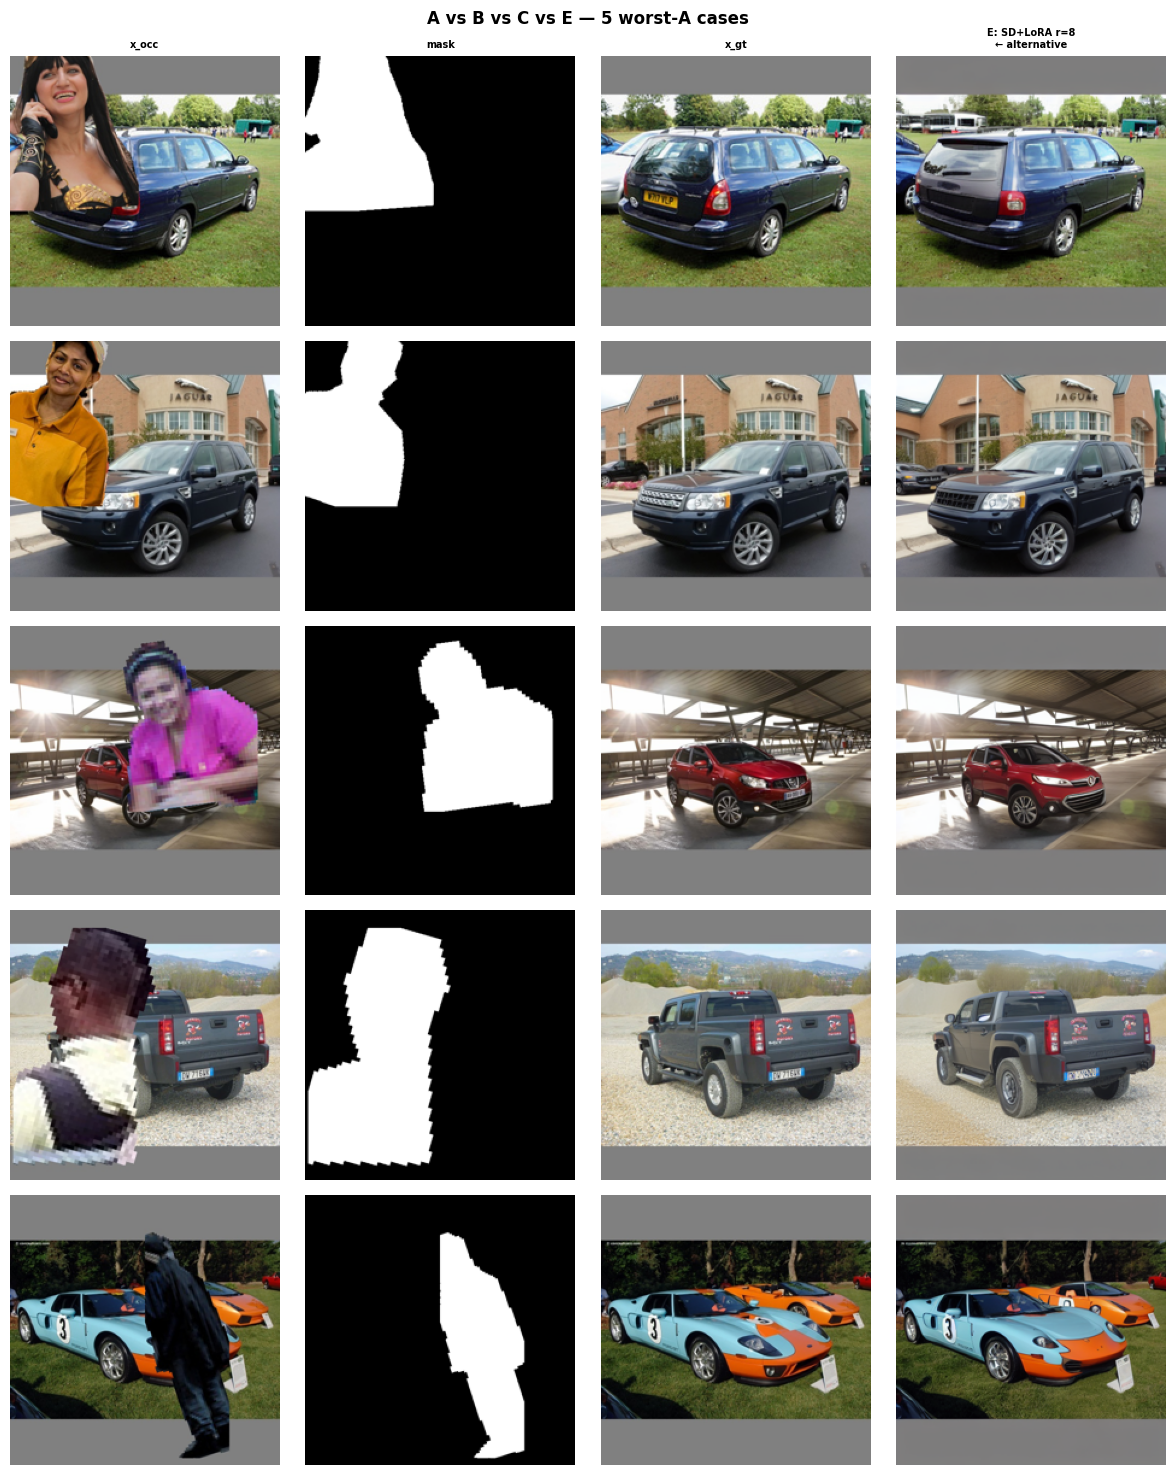

Saved: D:\CS331\DoAn\Occluded-Object-Restoration-CarsFocus\outputs\lora_sd\reports/comparison_A_B_C_E.png


In [9]:
# CELL 9 — Comparison: A vs C vs E  (5 worst-A cases)
# A = baseline, C = best non-LoRA, E = LoRA alternative
import matplotlib.pyplot as plt

a_csv = PROJECT_ROOT / "outputs" / "eval" / "metrics_per_image_A_SD_only.csv"
compare_stems = (
    pd.read_csv(a_csv).sort_values("ssim")["stem"].iloc[:5].tolist()
    if a_csv.exists() else worst20["stem"].iloc[:5].tolist()
)

configs = [
    (XHAT_A,  "A: SD only\n(baseline)"),
    (XHAT_B,  "B: SD+CN"),
    (XHAT_C,  "C: SD+CN+IP"),
    (PRED_DIR, f"E: SD+LoRA r={lora_rank}\n← alternative"),
]
avail  = [(d, lbl) for d, lbl in configs if d.exists() or d == PRED_DIR]
n_cols = 3 + len(avail)
col_titles = ["x_occ", "mask", "x_gt"] + [lbl for _, lbl in avail]

fig, axes = plt.subplots(len(compare_stems), n_cols,
                         figsize=(3.0*n_cols, 3.0*len(compare_stems)))
fig.suptitle("A vs B vs C vs E — 5 worst-A cases", fontsize=12, fontweight="bold")
if len(compare_stems) == 1: axes = np.expand_dims(axes, 0)

for ri, stem in enumerate(compare_stems):
    m_row = meta[meta["stem"]==stem]
    if len(m_row) == 0: continue
    m_row = m_row.iloc[0]
    occ = Image.open(OCC_DIR  / m_row["x_occ"]).convert("RGB").resize((224,224))
    msk = Image.open(MASK_DIR / f"{stem}.png").convert("L").resize((224,224))
    gt  = Image.open(GT_DIR   / m_row["x_gt"]).convert("RGB").resize((224,224))
    imgs = [np.array(occ), np.array(msk), np.array(gt)]
    for d, _ in avail:
        p = d / f"{stem}.png"
        imgs.append(np.array(Image.open(p).convert("RGB").resize((224,224))) if p.exists() else None)
    for ci, (img, title) in enumerate(zip(imgs, col_titles)):
        ax = axes[ri, ci]
        ax.imshow(img, cmap="gray" if ci==1 else None) if img is not None \
            else ax.text(0.5, 0.5, "N/A", ha="center", va="center", transform=ax.transAxes, color="gray")
        ax.axis("off")
        if ri == 0: ax.set_title(title, fontsize=7, fontweight="bold")
    e_row = metric_df[metric_df["stem"]==stem]
    if len(e_row) > 0:
        axes[ri, n_cols-1].set_xlabel(
            f"SSIM={e_row['ssim'].values[0]:.3f}  LP={e_row['lpips'].values[0]:.3f}", fontsize=7)

plt.tight_layout()
plt.savefig(REPORT_DIR / "comparison_A_B_C_E.png", dpi=130, bbox_inches="tight")
plt.show()
print(f"Saved: {REPORT_DIR}/comparison_A_B_C_E.png")

In [10]:
# CELL 10 — GPU Report + Final Summary
import subprocess
if torch.cuda.is_available():
    peak = torch.cuda.max_memory_allocated() / 1024**2
    print(f"Peak VRAM: {peak:.0f} MiB ({peak/1024:.2f} GiB)")
    try:
        print(subprocess.check_output(
            ["nvidia-smi", "--query-gpu=name,memory.total,memory.used,memory.free",
             "--format=csv,noheader,nounits"], stderr=subprocess.DEVNULL
        ).decode().strip())
    except Exception: pass

print(f"\nNotebook 08 complete — Config E (SD + LoRA r={lora_rank} only)")
print(f"  SSIM  mean   : {summary['ssim_mean']:.4f}")
print(f"  LPIPS mean   : {summary['lpips_mean']:.4f}")
print(f"  FID          : {summary['fid']:.2f}")
print(f"  Inference    : {infer_elapsed/60:.1f} min")
print(f"  Reports      : {REPORT_DIR}")
print()
print("─── Ablation chain tổng thể ───")
print("  A: SD only              → baseline")
print("  B: SD + ControlNet      → +shape prior")
print("  C: SD + CN + IP-Adapter → +surface prior")
print(f"  E: SD + LoRA(r={lora_rank})   → alternative (BẠN Ở ĐÂY)")
print(f"  F: LoRA + CN            → future work")
print(f"  G: LoRA + CN + IP       → future work")
print("\n→ Tiếp theo: re-run notebook 05 → 06")

Peak VRAM: 2954 MiB (2.88 GiB)
NVIDIA GeForce RTX 4050 Laptop GPU, 6141, 3346, 2576

Notebook 08 complete — Config E (SD + LoRA r=8 only)
  SSIM  mean   : 0.5925
  LPIPS mean   : 0.0573
  FID          : 22.10
  Inference    : 17.3 min
  Reports      : D:\CS331\DoAn\Occluded-Object-Restoration-CarsFocus\outputs\lora_sd\reports

─── Ablation chain tổng thể ───
  A: SD only              → baseline
  B: SD + ControlNet      → +shape prior
  C: SD + CN + IP-Adapter → +surface prior
  E: SD + LoRA(r=8)   → alternative (BẠN Ở ĐÂY)
  F: LoRA + CN            → future work
  G: LoRA + CN + IP       → future work

→ Tiếp theo: re-run notebook 05 → 06
